In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cleaned_data.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'patient_id', 'age', 'gender', 'neighborhood',
       'scheduled_day', 'appointment_day', 'waiting_days', 'appointment_hour',
       'month', 'sms_received', 'reminder_calls', 'previous_appointments',
       'previous_no_shows', 'no_show_rate', 'distance_km',
       'transportation_type', 'has_chronic_disease', 'hypertension',
       'diabetes', 'alcoholism', 'disability', 'appointment_type',
       'doctor_specialty', 'clinic_type', 'weather_condition',
       'temperature_celsius', 'rainy_day', 'employment_status', 'income_level',
       'marital_status', 'children_count', 'patient_satisfaction_score',
       'no_show_probability', 'no_show'],
      dtype='object')

#### In this part, we vastly will compare specifiq column with the "no_show" data. We might give importance in the "no_show = 1" data which means we want to identify which data are responsible behind a patient's not attending in the follow-up date. We will also analyze mutual data dependency of columns except "no_show" data.

## Gender-wise no_show data

Text(0.5, 0, '1=no show, 0=show')

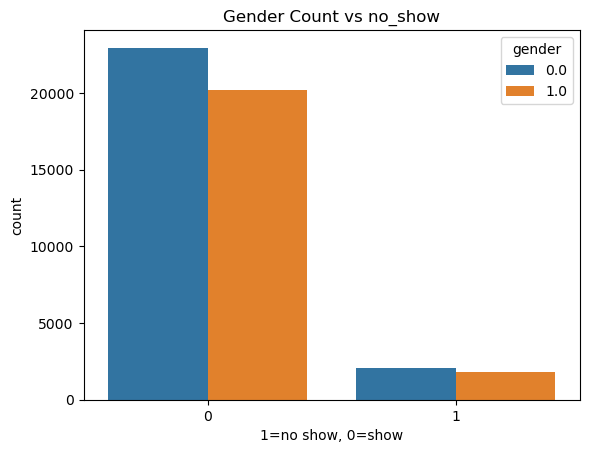

In [4]:
sns.countplot(data=df,hue='gender',x='no_show')
plt.title('Gender Count vs no_show')
plt.xlabel('1=no show, 0=show')

If we look at the chart, it is visible that for both male and female the show:no_show rate is quite same. So it is difficult to say that one sex group may show higher no show probabilty than the other.

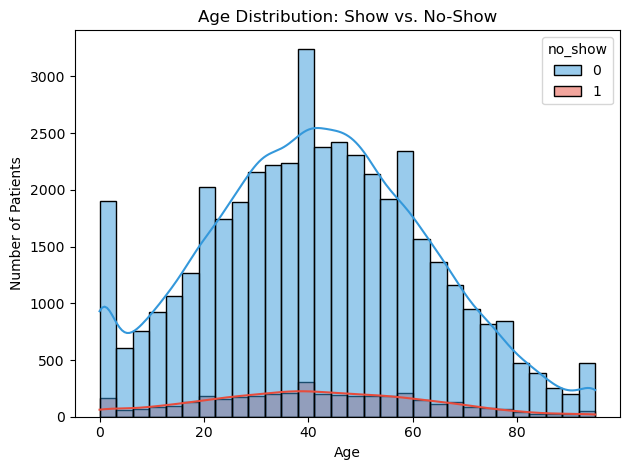

In [5]:
sns.histplot(data=df, x='age', hue='no_show', kde=True, bins=30, palette=['#3498db', '#e74c3c'])
plt.title('Age Distribution: Show vs. No-Show')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

It is visible from the graph that as expected the blue columns completely dwarfed the red ones as maximum patients tend to show up. Other than this, the more the number of patients do show up, the rate of no_show is higher proportionally. We cannot find any particular group with imbalance of this rate.

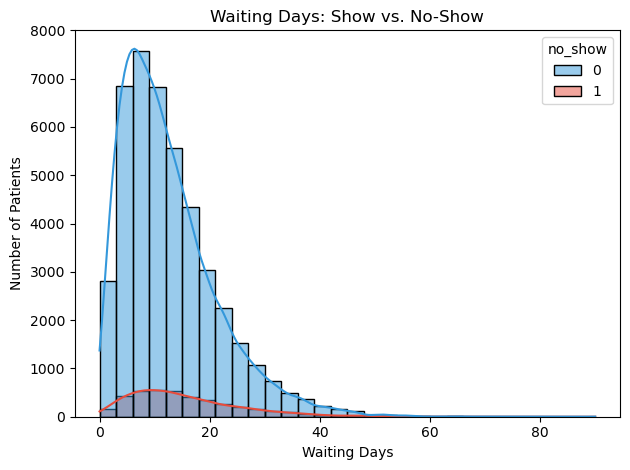

In [6]:
sns.histplot(data=df, x='waiting_days', hue='no_show', kde=True, bins=30, palette=['#3498db', '#e74c3c'])
plt.title('Waiting Days: Show vs. No-Show')
plt.xlabel('Waiting Days')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

Unlike the age distribution, analyzing the 'Waiting Days' variable reveals a clear behavioral trend. The overlapping KDE plots show a heavily right-skewed distribution, with the vast majority of appointments scheduled within a 10-day window. Crucially, the peak of the no-show (red) distribution is shifted further to the right compared to the attended (blue) distribution. This visual discrepancy suggests a positive correlation between longer wait times and higher no-show rates, indicating that appointment lead time is a strong predictive feature.

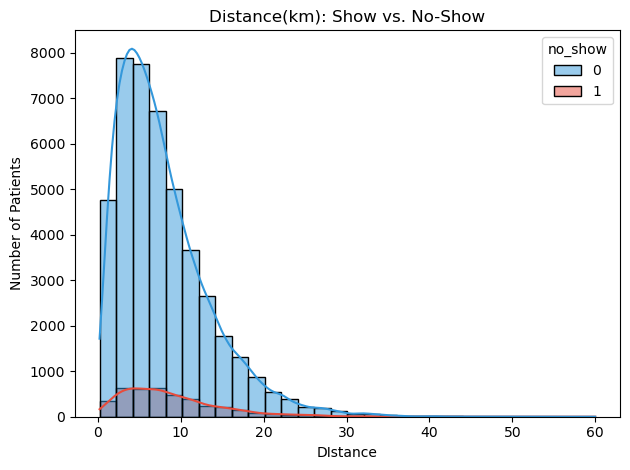

In [7]:
sns.histplot(data=df, x='distance_km', hue='no_show', kde=True, bins=30, palette=['#3498db', '#e74c3c'])
plt.title('Distance(km): Show vs. No-Show')
plt.xlabel('DIstance')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

Visualizing the 'Distance' variable reveals a highly right-skewed distribution, indicating that most patients reside close to the clinic. Importantly, the KDE curves for both attended and missed appointments follow nearly identical shapes and peak at the same distance range. This proportional scaling suggests that, unlike waiting time, absolute travel distance does not disproportionately increase the likelihood of a patient missing an appointment.

In [8]:
counts_table = pd.crosstab(df['has_chronic_disease'], df['no_show'])
counts_table

no_show,0,1
has_chronic_disease,,
0,27152,2550
1,16886,1412


Text(0.5, 0, '1=has_chronic_disease, 0=no_chronic_disease')

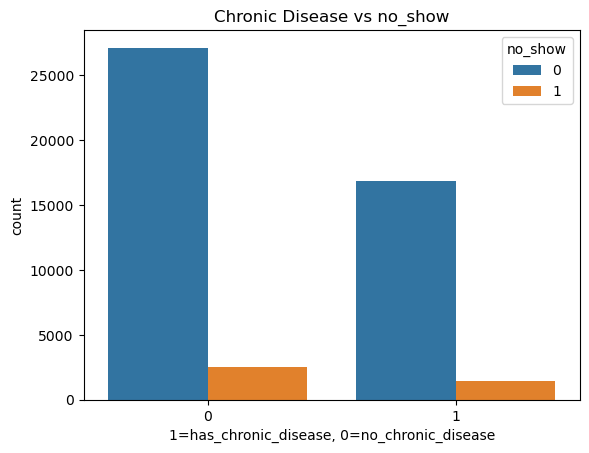

In [9]:
sns.countplot(data=df,hue='no_show',x='has_chronic_disease')
plt.title('Chronic Disease vs no_show')
plt.xlabel('1=has_chronic_disease, 0=no_chronic_disease')

Here, percentage of patient without chronic disease for not showing up is 9.3915%. Whereas this ratio for with chronic disease is 8.3619%. This implies that patients having chronic disease might have a higher rate of showing up in the next appointment.

In [10]:
counts_table = pd.crosstab(df['hypertension'], df['no_show'])
counts_table

no_show,0,1
hypertension,,
0,30131,2680
1,13907,1282


Patient has Hypertension: 1282/13907=9.2183%, 
Patient without Hypertension: 2680/30131= 8.8944%,   As the no_show 1:0 ratio is slightly higher for patient with hypertension, this reveals that these patients are more likely to miss the appointment in the date.

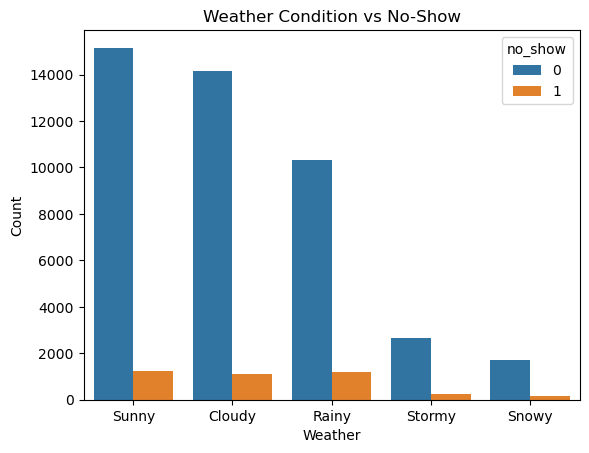

In [11]:
sns.countplot(data=df, hue='no_show', x='weather_condition')
plt.title('Weather Condition vs No-Show')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.show()

In [12]:
counts_table = pd.crosstab(df['weather_condition'], df['no_show'])
counts_table

no_show,0,1
weather_condition,,
Cloudy,14173,1117
Rainy,10336,1197
Snowy,1717,161
Stormy,2656,267
Sunny,15156,1220


As per assumed, the percentage of no_show is the highest in the rainy or stormy days compared to other situations. All other weather condition cluster to a pretty same ratio.

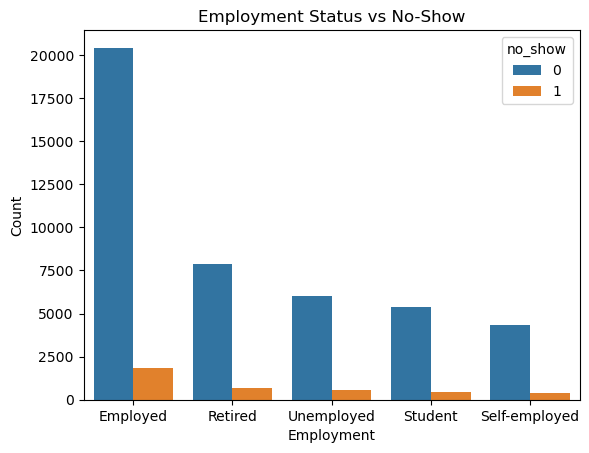

In [13]:
sns.countplot(data=df, hue='no_show', x='employment_status')
plt.title('Employment Status vs No-Show')
plt.xlabel('Employment')
plt.ylabel('Count')
plt.show()

This grouped bar chart analyzes appointment attendance across different employment statuses. While 'Employed' patients represent the vast majority of the total appointment volume, a visual comparison of the show/no-show ratios reveals an important behavioral trend. The 'Retired' demographic displays a proportionally much smaller no-show bar (orange) relative to its total attendances (blue) when compared to the other groups. This suggests that retired patients are the most reliable demographic and are significantly less likely to miss an appointment.

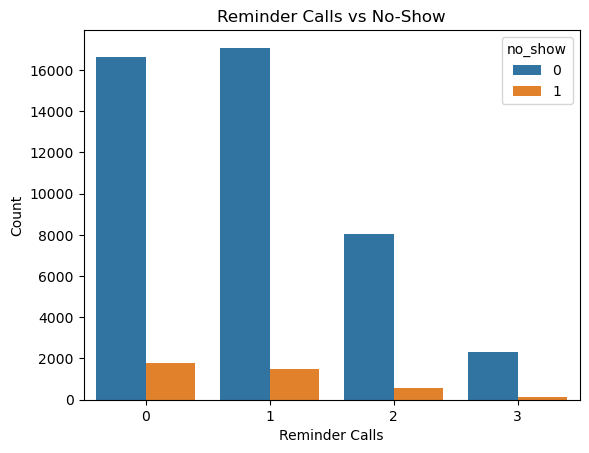

In [14]:
sns.countplot(data=df, hue='no_show', x='reminder_calls')
plt.title('Reminder Calls vs No-Show')
plt.xlabel('Reminder Calls')
plt.ylabel('Count')
plt.show()

It is evident from the graph that patients who recieved at least 1 reminder calls are higher in SHOW and lower in NO SHOW compared to patients who received no reminder calls at all. This reveals the necessity of reminder calls in successful patient presence.

Text(0.5, 0, '1=Received, 0=Not received')

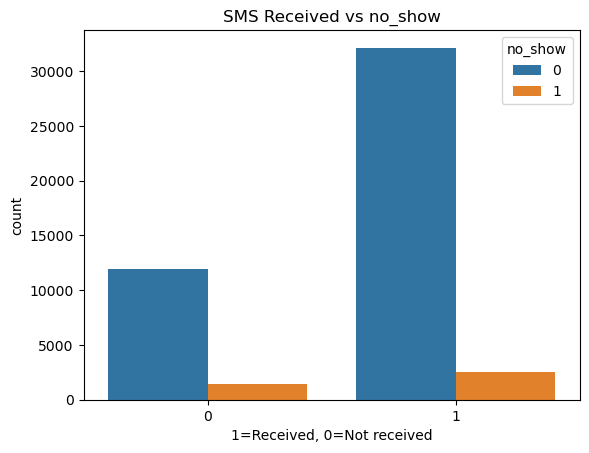

In [16]:
sns.countplot(data=df,hue='no_show',x='sms_received')
plt.title('SMS Received vs no_show')
plt.xlabel('1=Received, 0=Not received')

In [18]:
counts_table = pd.crosstab(df['sms_received'], df['no_show'])
counts_table

no_show,0,1
sms_received,,
0,11907,1456
1,32131,2506


Those who did not receive sms, 12.2281% of them did not show up in the follow date whereas Those who did receive sms, only 7.7993% did not show up in the date. This implies that sending SMS is a vital factor behind the show up of the patients in the follow-up date. The management should emphasize this prediction. 

## Insights:

1. There is a clear positive correlation between longer wait times and higher no-show rates. Patients forced to wait several weeks are highly prone to missing their appointments.
2. Patients managing chronic conditions (Group 1) have a visibly lower no-show-to-show ratio than healthier patients (Group 0). This suggests that the ongoing necessity of disease management acts as a protective factor against missed appointments, making these patients inherently more reliable.
3. The 'Retired' cohort demonstrated the lowest proportional no-show rate of any employment category. This indicates that schedule flexibility and healthcare prioritization lead to superior appointment adherence for this group.
4. Looking strictly at absolute counts, the shape of the no-show distribution identically mirrors the overall attendance volume. Missed appointments essentially scale proportionally with the baseline age demographics, requiring deeper normalized percentage calculations to isolate specific age-based risks.

## Recommendations

1. Targeting Wait Times: Implementing an automated waitlist system to fill gaps, prioritizing getting patients seen within the critical 0–10 day window.
2. Dynamic Reminders: Deploying heavy, multi-channel automated reminders specifically for employed individuals and patients without chronic diseases, as they exhibit higher baseline unreliability.